In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications.vgg16 import preprocess_input


(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)


def preprocess_image(image, label):

    image = tf.image.resize(image, (150, 150))

    image = preprocess_input(image)
    return image, label


train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)


for image, label in train_ds.take(1):
    print(f'Image shape: {image.shape}')
    print(f'Label: {label}')

print('Dataset loaded and preprocessed successfully.')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.J0G8D7_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Image shape: (150, 150, 3)
Label: 1
Dataset loaded and preprocessed successfully.


In [3]:
import tensorflow as tf
from tensorflow.keras import layers


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])


train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE)


BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

train_ds = train_ds.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data augmentation and batching complete.")
print(f"Training dataset: {train_ds}")
print(f"Validation dataset: {val_ds}")

Data augmentation and batching complete.
Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [4]:
from tensorflow.keras.applications import VGG16


base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


base_model.trainable = False


base_model.summary()

print('\nVGG16 base model loaded and frozen successfully.')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)


VGG16 base model loaded and frozen successfully.


In [5]:
from tensorflow.keras import models, layers


model = models.Sequential([
    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])


model.summary()

print('\nCustom classification layers added to the VGG16 base successfully.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Custom classification layers added to the VGG16 base successfully.


In [6]:

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


print('Starting training...')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print('\nTraining completed.')

Starting training...
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 198s 314ms/step - accuracy: 0.8717 - loss: 0.8009 - val_accuracy: 0.9647 - val_loss: 0.1401
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 177s 294ms/step - accuracy: 0.8963 - loss: 0.2933 - val_accuracy: 0.9665 - val_loss: 0.1063
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 178s 294ms/step - accuracy: 0.9067 - loss: 0.2387 - val_accuracy: 0.9688 - val_loss: 0.0963
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 203s 297ms/step - accuracy: 0.9116 - loss: 0.2227 - val_accuracy: 0.9708 - val_loss: 0.0861
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 177s 294ms/step - accuracy: 0.9192 - loss: 0.1999 - val_accuracy: 0.9725 - val_loss: 0.0838
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 177s 295ms/step - accuracy: 0.9218 - loss: 0.1936 - val_accuracy: 0.9725 - val_loss: 0.0812
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 178s 296ms/step - accuracy: 0.9238 - loss: 0.1857 - val_accuracy: 0.9733 - val_loss: 0.0839
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 201s 295ms/step

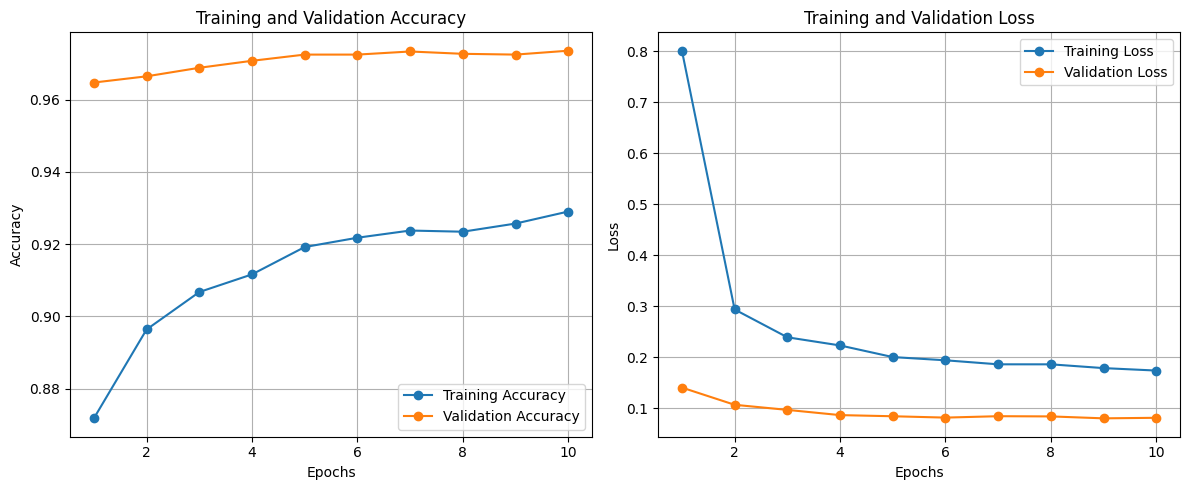

In [7]:
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()